In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
5,66,Male,asymptomatic,160,228,False,lv hypertrophy,138,False,2.3,upsloping,fixed defect,0
6,56,Male,non-anginal,130,276,False,normal,128,True,1.0,upsloping,fixed defect,0
7,48,Male,non-anginal,110,211,False,normal,138,False,0.0,downsloping,fixed defect,0
8,57,Male,atypical angina,140,260,True,normal,140,False,0.0,downsloping,fixed defect,0
9,53,Male,non-anginal,155,175,True,st-t abnormality,160,False,NaN,upsloping,fixed defect,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [25]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [26]:
df.shape

(908, 13)

In [27]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

as you can see there are some null values in the dataset in the oldpeak column

In [28]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [29]:
df['target']= df['num'].apply(lambda x: 0 if  x== 0 else 1)
df['target'].value_counts()

target
1    509
0    399
Name: count, dtype: int64

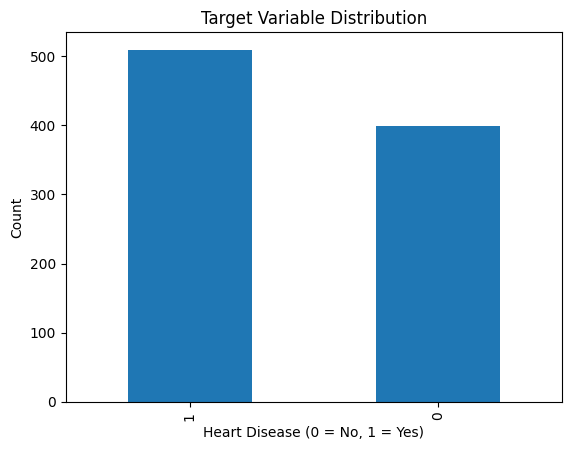

In [30]:
df['target'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


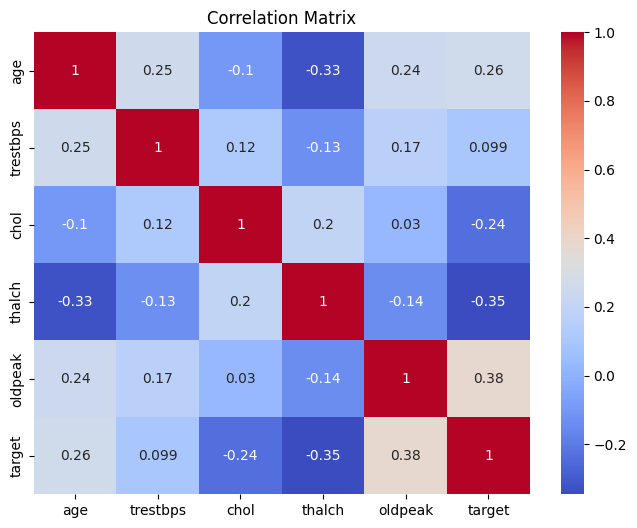

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['age','trestbps','chol','thalch','oldpeak','target']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


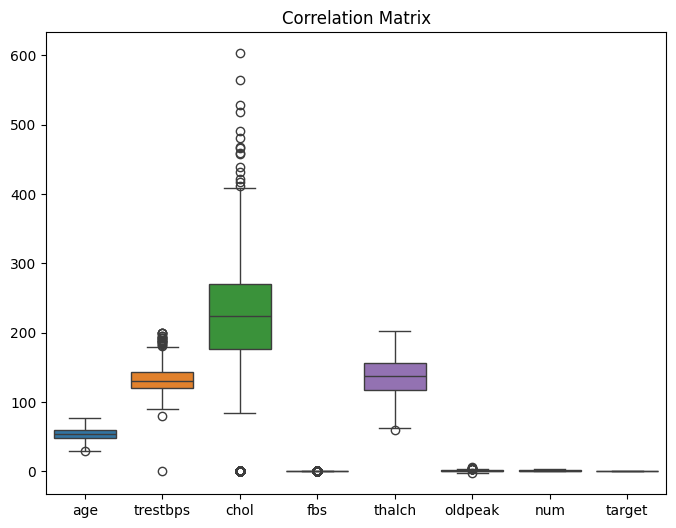

In [32]:
plt.figure(figsize=(8,6))
sns.boxplot(data= df)
plt.title("Correlation Matrix")
plt.show()


In [33]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [34]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
target      0
dtype: int64

In [35]:
df.drop(columns=['num'], inplace=True)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  target    908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


as you can clearly see in the boxplot that there are many outliers in some columns such as cholesterol, oldpeak,trestbps etc. we will retain the outlier since in medical data it can be fatal if removed some medical signals these outliers may represent. Decision tree is robust to the outliers.missing values were observed only in the oldpeak feature and were treated using median imputation to ensure robustness against outliers

# Feature Engineering

In [37]:

df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'],
    drop_first=True
)

df_encoded.head()


,age,trestbps,chol,fbs,thalch,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,0,True,False,False,True,False,False,False,False,False,False,False,False,False
1,41,135,203,False,132,0.0,0,True,True,False,False,True,False,False,False,False,True,False,False,False
2,57,140,192,False,148,0.4,0,True,False,False,False,True,False,False,False,False,True,False,False,False
3,52,118,186,False,190,0.0,0,True,False,False,True,False,False,False,False,False,True,False,False,False
4,57,110,201,False,126,1.5,0,True,False,False,False,True,False,True,False,False,True,False,False,False


In [38]:

X = df_encoded.drop(columns=['target'])
y = df_encoded['target']


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


feature engineering was performed by encoding categorical variables using one hot encoding to convert them into a machine readable format without introducing artificial ordinal relationships. the dataset was split in 80-20 ratio.

# model training

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [43]:
y_pred = dt_model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


Accuracy: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68        80
           1       0.75      0.75      0.75       102

    accuracy                           0.71       182
   macro avg       0.71      0.71      0.71       182
weighted avg       0.71      0.71      0.71       182



array([[54, 26],
       [26, 76]], dtype=int64)

the model accurately predicts heart disease 71 % of the times.but precision and recall is low  resulting in some healthy patients being wrongly classifies as diseased. when the model predicts heart disease it is correct 75 % of times . it successfull detects 75 % actual heart disease cases.

However, the confusion matrix reveals that 26 patients with heart disease were misclassified as healthy, highlighting the need for further model optimization. Overall, the baseline model provides reasonable performance but requires improvement to reduce false negatives.

# hyperparameter tuning

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_


{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 20}

In [47]:
best_dt = grid_search.best_estimator_

best_dt.fit(X_train, y_train)

y_pred_tuned = best_dt.predict(X_test)


In [48]:
y_pred_tuned

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1], dtype=int64)

# model evaluation and analysis with decision tree

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))
confusion_matrix(y_test, y_pred_tuned)


Accuracy: 0.7637362637362637

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.69      0.72        80
           1       0.77      0.82      0.80       102

    accuracy                           0.76       182
   macro avg       0.76      0.76      0.76       182
weighted avg       0.76      0.76      0.76       182



array([[55, 25],
       [18, 84]], dtype=int64)

you can see above that accuracy increased from 71 to 76 , which means that hyperparameter tuning worked here.this model now correctly identifies the 82% of patients with heart disease this is a major improvement in medical context. precision is 0.77 and f1 score is 0.80 which is also good.

as you can see from the confusion matrix that false negatives are reduced from 26 to 18 while true positives increased from 76 to 84. the tuned model misses 8 fewer heart disease cases, which is clinically significant.

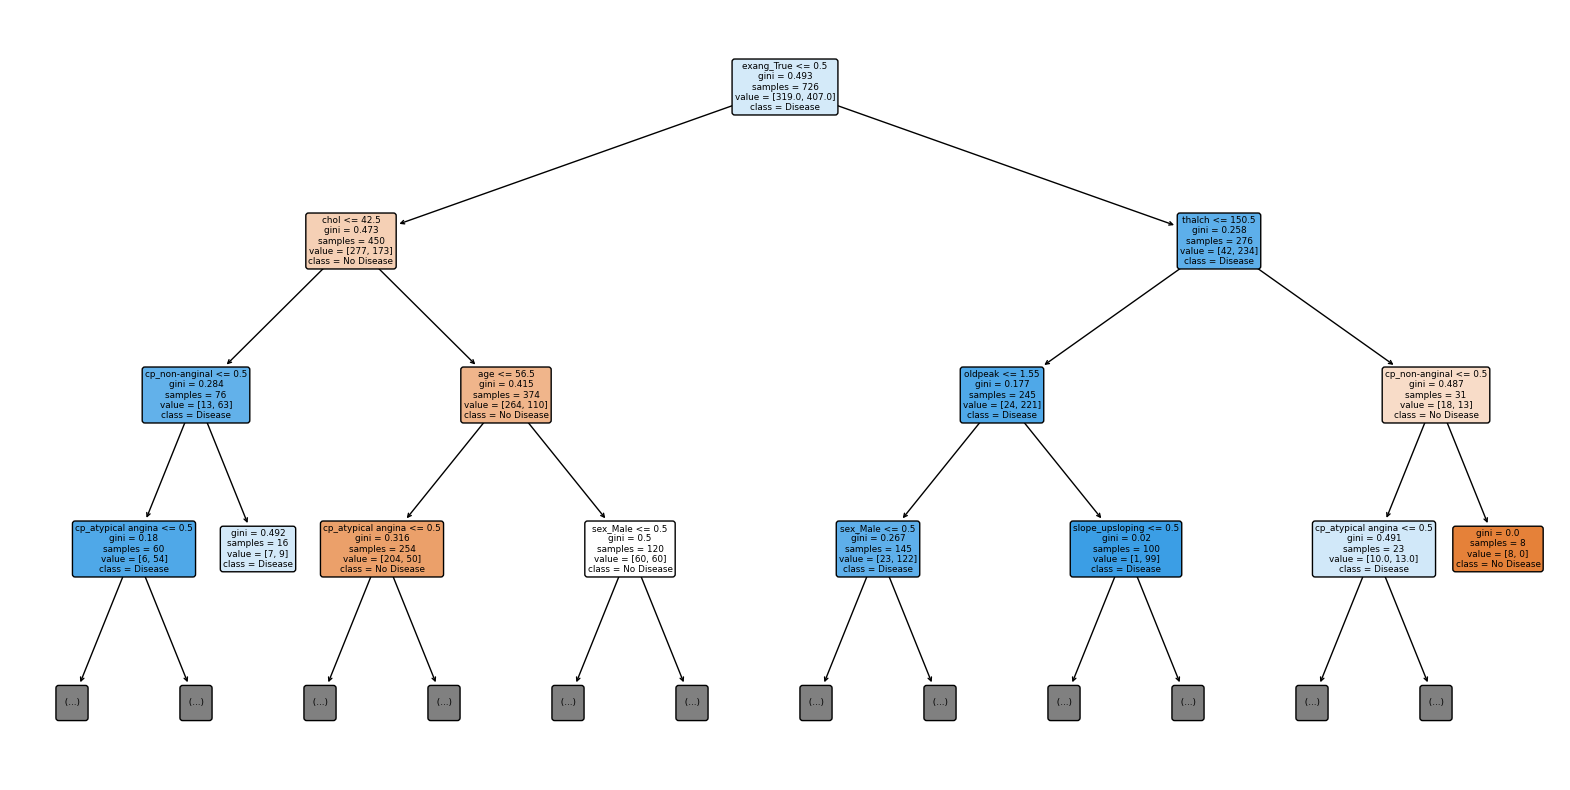

In [51]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.show()


The visualized Decision Tree illustrates how clinical features such as exercise-induced angina, ST depression (oldpeak), and maximum heart rate (thalch) contribute to heart disease prediction. Features appearing closer to the root node are more influential in decision-making, highlighting their importance in the mode

# Interview Questions

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

    following are some of the hyperparameters of decision tree models:

   1.max_depth: it controls tree complexity. it controls how deep a tree can grow during training.

    2.min_samples_split: prevents overfitting. it indicates that there are minimal number of samples required before the internal split.


    3.criterion: it measure of split quality.

2. What is the difference between the Label encoding and One-hot encoding?

In machine learning, categorical variables must be converted into numerical form for algorithms to process them effectively. Label Encoding and One-Hot Encoding are two widely used techniques for this transformation, each suited for different types of categorical data.

    one hot encoding: One-Hot Encoding creates a new binary column for each category, marking presence with 1 and absence with 0. it works for nominal data which has no inheritant order.
    
    Label-encoding: Label Encoding assigns each unique category an integer value. It’s efficient in terms of memory and works well for ordinal data where categories have a natural order